In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-object-detection/data/sample_submission.csv
/kaggle/input/car-object-detection/data/train_solution_bounding_boxes (1).csv
/kaggle/input/car-object-detection/data/testing_images/vid_5_26420.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_31520.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_29420.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_31720.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_26560.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_27840.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_28560.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_28360.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_25240.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_29560.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_29020.jpg
/kaggle/input/car-object-detection/data/testing_images/vid_5_30720.jpg
/kaggle/

In [2]:
import cv2
import matplotlib.pyplot as plt


In [3]:
!git clone https://github.com/pjreddie/darknet
!cd darknet
!make

Cloning into 'darknet'...
remote: Enumerating objects: 5955, done.
remote: Total 5955 (delta 0), reused 0 (delta 0), pack-reused 5955 (from 1)
Receiving objects: 100% (5955/5955), 6.37 MiB | 33.29 MiB/s, done.
Resolving deltas: 100% (3932/3932), done.
make: *** No targets specified and no makefile found.  Stop.


In [4]:
!wget https://pjreddie.com/media/files/yolov3.weights

--2025-03-20 09:09:30--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  15.5MB/s    in 25s     

2025-03-20 09:11:32 (9.57 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]



In [5]:
net = cv2.dnn.readNet("./yolov3.weights", "./darknet/cfg/yolov3.cfg")

In [6]:
classes = []
with open("./darknet/data/coco.names","r") as f:
    classes = [line.strip() for line in f.readlines()]

In [7]:
layer_names = net.getLayerNames()
output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]


In [8]:
def predict_img(path):
    img = cv2.imread(path)
    height, width, channels = img.shape
    blob = cv2.dnn.blobFromImage(img, 1 / 255.0, (416, 416),
         swapRB=True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)
    class_ids = []
    confidences = []
    boxes = []
    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:
                    # Object detected
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)

                    # Rectangle coordinates
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
    colors = np.random.uniform(0, 255, size=(len(classes), 3))
    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            color = colors[class_ids[i]]
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            cv2.putText(img, label, (x, y -5),cv2.FONT_HERSHEY_SIMPLEX,1/2, color, 2)
    plt.imshow(img)

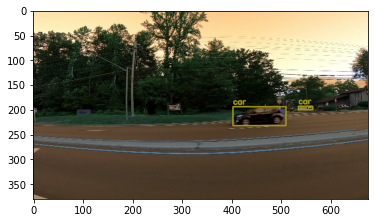

In [9]:
predict_img("../input/car-object-detection/data/training_images/vid_4_10980.jpg")

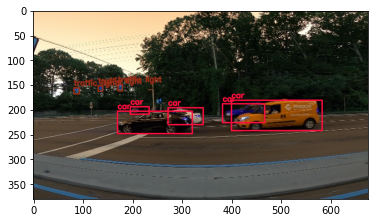

In [10]:
predict_img("../input/car-object-detection/data/training_images/vid_4_12300.jpg")

In [13]:
image = cv2.imread("../input/car-object-detection/data/training_images/vid_4_12300.jpg")

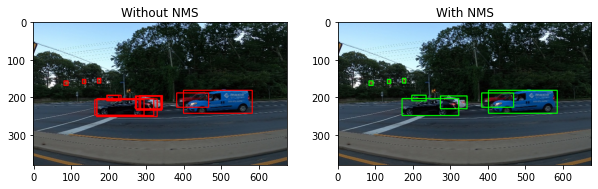

In [14]:

# Perform object detection
layer_names = net.getLayerNames()
output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]
blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
net.setInput(blob)
layer_outputs = net.forward(output_layers)

# Post-processing without NMS
boxes, confidences, class_ids = [], [], []
h, w = image.shape[:2]

for output in layer_outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:  # Threshold
            center_x, center_y, width, height = (detection[0:4] * np.array([w, h, w, h])).astype("int")
            x, y = int(center_x - (width / 2)), int(center_y - (height / 2))
            boxes.append([x, y, int(width), int(height)])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Draw detections without NMS
image_no_nms = image.copy()
for i in range(len(boxes)):
    x, y, w, h = boxes[i]
    cv2.rectangle(image_no_nms, (x, y), (x + w, y + h), (0, 0, 255), 2)

# Apply NMS
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
image_nms = image.copy()

if len(indices) > 0:
    for i in indices.flatten():
        x, y, w, h = boxes[i]
        cv2.rectangle(image_nms, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Display both results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image_no_nms, cv2.COLOR_BGR2RGB))
plt.title("Without NMS")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image_nms, cv2.COLOR_BGR2RGB))
plt.title("With NMS")
plt.show()
